In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random as rnd
import statistics

normal_dist = statistics.NormalDist(0., 1.)

## Modèle de Heston

On considère un actif dont le processus de prix $(S_t)_{t \geq 0}$ suit une dynamique de type Heston comme suit:
$$
\left\{
\begin{aligned}
\mathrm{d} S_t && = && r S_t \mathrm{d} t + \sqrt{\nu_t} S_t \mathrm{d} W_t^{[S]}\\
\mathrm{d} \nu_t && = && \kappa \left(\theta - \nu_t\right) \mathrm{d} t + \xi \sqrt{\nu_t} \mathrm{d} W_t^{[\nu]}\\
\mathrm{d} \left\langle W^{[S]}, W^{[\nu]} \right\rangle_t && = && \rho \mathrm{d} t
\end{aligned}
\right.
$$

où $(\nu_t)_t$ est un processus supplémentaire representant la *variance instantannée*, $r, \kappa, \theta, \xi, S_0, \nu_0$ sont des paramètres strictement positifs et déterministes, et $W_t^{[S]}$ et $W_t^{[\nu]}$ sont deux browniens standards corrélés avec $\rho \in [-1, 1]$ (corrélation également déterministe ici).

On suppose que la condition de Feller $2 \kappa \theta > \xi^2$ est vérifiée, ce qui permet d'avoir $\nu_t > 0$ presque-sûrement.

Soient $K > 0$ et $T > 0$. Nous allons chercher à approcher $C_0 = e^{-r T} \mathbb{E}\left[\left(S_T - K\right)^+\right]$ et $P_0 = e^{-r T} \mathbb{E}\left[\left(K - S_T\right)^+\right]$ par Monte-Carlo.

En log-espace, la dynamique précédente se réécrit:
$$
\left\{
\begin{aligned}
\mathrm{d} \log\left(S_t\right) && = && \left(r - \frac{\nu_t}{2}\right) \mathrm{d} t + \sqrt{\nu_t} \mathrm{d} W_t^{[S]}\\
\mathrm{d} \nu_t && = && \kappa \left(\theta - \nu_t\right) \mathrm{d} t + \xi \sqrt{\nu_t} \mathrm{d} W_t^{[\nu]}\\
\mathrm{d} \left\langle W^{[S]}, W^{[\nu]} \right\rangle_t && = && \rho \mathrm{d} t
\end{aligned}
\right.
$$

Notons que nous pouvons réécrire cette dynamique en utilisant directement deux browniens indépendants $\widetilde{W}^{[S]}$ et $\widetilde{W}^{[\nu]}$ en via une décomposition de Cholesky:
$$
\left\{
\begin{aligned}
\mathrm{d} \log\left(S_t\right) && = && \left(r - \frac{\nu_t}{2}\right) \mathrm{d} t + \sqrt{\nu_t} \mathrm{d} \widetilde{W}_t^{[S]}\\
\mathrm{d} \nu_t && = && \kappa \left(\theta - \nu_t\right) \mathrm{d} t + \xi \sqrt{\nu_t} \left(\rho \mathrm{d} \widetilde{W}_t^{[S]} + \sqrt{1 - \rho^2} \widetilde{W}^{[\nu]} \right)
\end{aligned}
\right.
$$

Nous allons ensuite introduire un schéma numérique de type Euler-Maruyama, en utilisant une troncature sur $\nu$ afin d'éviter les valeurs négatives sous les racines. Nous considérons ici une discrétisation en temps $0 =: t_0 < t_1 < \dots < t_n := T$ à pas constant $h$ (*i.e.* $t_i = i h$ et $h = \frac{T}{n}$). Soient alors $(\widehat{S}_{t_i})_{0 \leq i\leq }$ et $(\widehat{\nu}_{t_i})_{0 \leq i\leq }$ des variables aléatoires réelles tels que:

$$
\left\{
\begin{aligned}
\log\left(\widehat{S}_{t_{i + 1}}\right) && = && \log\left(\widehat{S}_{t_i}\right) + \left(r - \frac{\left(\widehat{\nu}_{t_i}\right)^+}{2}\right) h + \sqrt{h \left(\widehat{\nu}_{t_i}\right)^+} Z^{[S]}_{i + 1}\\
\widehat{\nu}_{t_{i + 1}} && = && \widehat{\nu}_{t_i} + \kappa \left(\theta - \left(\widehat{\nu}_{t_i}\right)^+\right) h + \xi \sqrt{h \left(\widehat{\nu}_{t_i}\right)^+} \left(\rho Z^{[S]}_{i + 1} + \sqrt{1 - \rho^2} Z^{[\nu]}_{i + 1} \right)
\end{aligned}
\right.
$$

où $Z^{[S]}_1, Z^{[S]}_2, \dots, Z^{[S]}_n, Z^{[\nu]}_1, Z^{[\nu]}_2, \dots, Z^{[\nu]}_n$ sont des tirages i.i.d de la loi $\mathcal{N}(0, 1)$ et $\widehat{S}_{t_0} = S_0$ et $\widehat{\nu}_{t_0} = \nu_0$.

1 - Ecrire une fonction `single_step` qui prend en entrée `x` (censé jouer le rôle de $\log(\widehat{S}_{t_i})$), `y` (censé jouer le rôle de $\widehat{\nu}_{t_i}$), `r`, `kappa`, `theta`, `xi`, ,`rho` et `h` et qui sort une réalisation du couple $(\widehat{S}_{t_{i + 1}}, \widehat{\nu}_{t_{i + 1}})$ sachant $(\widehat{S}_{t_i}, \widehat{\nu}_{t_i}) = (x, y)$. Comme dans le TP 4, vous allez devoir en particulier vous servir de la fonction `gauss` du module `random` importé sous l'alias `rnd` tout en haut. En particulier, pour générer une réalisation de la loi $\mathcal{N}(0,1)$, il suffit d'appeler `rnd.gauss()`.

In [2]:
def single_step(x, y, r, kappa, theta, xi, rho, h):
    y_pos = max(y, 0.0)
    z_x = rnd.gauss()
    z_y = rnd.gauss()
    x = x + (r - 0.5 * y_pos) * h + math.sqrt(h * y_pos) * z_x
    y = y + kappa * (theta - y_pos) * h + xi * math.sqrt(h * y_pos) * (rho * z_x + math.sqrt(1.0 - rho * rho) * z_y)
    return x, y

2- Ecrire une fonction `generate_path` qui prend en entrée `logS0`, `nu0`, `r`, `kappa`, `theta`, `xi`, ,`rho` et `T`, `n` et qui vous donne en sortie une trajectoire de $\widehat{S}$ sous forme d'une liste constituée de `logS0`, suivie d'une réalisation de $\log(\widehat{S}_{t_1})$, suivie d'une réalisation de $\log(\widehat{S}_{t_2})$ sachant $\log(\widehat{S}_{t_1})$, ..., jusqu'à arriver à la maturité $T$ où vous aurez une réalisation de $\log(\widehat{S}_{t_n})$ et similairement la trajectoire de $\widehat{\nu}$ ayant accompagné $\widehat{S}$.

In [88]:
def generate_path(logS0, nu0, r, kappa, theta, xi, rho, T, n):
    h = T / n
    logS_path = [None] * (n + 1)
    nu_path = [None] * (n + 1)
    logS = logS0
    nu = nu0
    logS_path[0] = logS
    nu_path[0] = nu
    for i in range(n):
        logS, nu = single_step(logS, nu, r, kappa, theta, xi, rho, h)
        logS_path[i + 1] = logS
        nu_path[i + 1] = nu
    return logS_path, nu_path

3- Tracez par exemple 16 trajectoires en prenant $S_0 = 1.0$, $\nu_0 = 0.1$, $r = 0.02$, $\kappa = 1.0$, $\theta = 0.1$, $\xi = 0.41$, $\rho = -0.4$, $T = 1.0$ et $n = 128$. Vous pouvez par aillers vérifier que ces paramètres vérifient bien la condition de Feller. Essayez de voir ce qui se passe lorsque celle-ci n'est plus vérifiée (par exemple prenez $\xi = 1.0$ au lieu de $0.41$).

(n'oubliez pas d'appliquer un log sur la valeur initiale avant de la donner en entrée à `generate_path`, et il faudra aussi passer à l'exponentielle sur la trajectoire résultante si vous voulez visualiser les trajectoires de $S$ et non de son log)

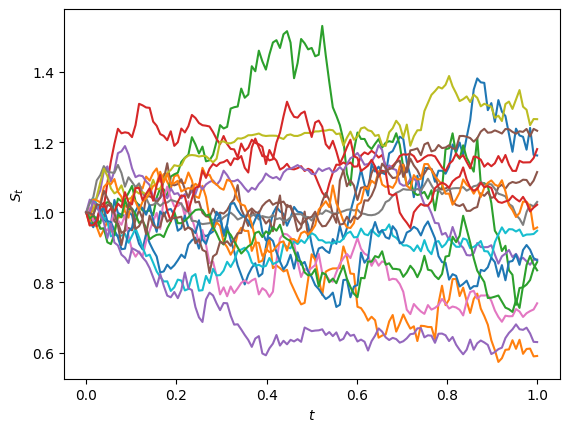

In [89]:
tmp_t_grid = np.linspace(0., 1., 129)
for i in range(16):
    tmp_S_path, tmp_nu_path = generate_path(0.0, 0.1, 0.02, 1.0, 0.1, 0.41, -0.4, 1.0, 128)
    plt.plot(tmp_t_grid, [math.exp(s) for s in tmp_S_path])
plt.xlabel('$t$')
plt.ylabel(r'$S_t$');

4- Donner deux estimateurs Monte Carlo des prix $C_0$ et $P_0$. Implémentez-les sous la forme d'une seule fonction `price_call_put` qui prend en entrée `S0`, `nu0`, `r`, `kappa`, `theta`, `xi`, ,`rho`, `T` `K`, `n`, un nombre `num_paths` de trajectoires, un booléen `call_put` ainsi qu'un seuil de risque `alpha` et qui donne en sortie une estimation par Monte Carlo de $C_0$ si le booléen est à `True` et de $P_0$ sinon, et également une paire constituée des deux bornes d'un intervalle de confiance approché au seuil de confiance $1 - \alpha$.

In [111]:
def price_call_put(S0, nu0, r, kappa, theta, xi, rho, T, K, n, num_paths, call_put, alpha):
    acc = 0.0
    acc_squares = 0.0
    logS0 = math.log(S0)
    for i in range(num_paths):
        ST = math.exp(generate_path(logS0, nu0, r, kappa, theta, xi, rho, T, n)[0][-1])
        payoff = max(ST - K, 0.) if call_put else max(K - ST, 0.)
        acc += payoff
        acc_squares += payoff * payoff
    acc *= math.exp(-r * T) / num_paths
    acc_squares *= math.exp(-2.0 * r * T) / num_paths
    stdev = math.sqrt(acc_squares - acc * acc)
    z = normal_dist.inv_cdf(1.0 - 0.5 * alpha)
    half_length = z * stdev / math.sqrt(num_paths)
    return acc, (acc - half_length, acc + half_length)

5- On admet l'approximation COS suivante, où l'idée essentielle est d'approcher la fonction densité par un développement en série de Fourier tronquée (voir http://ta.twi.tudelft.nl/mf/users/oosterle/oosterlee/COS.pdf, ou encore le bouquin *"Mathematical Modeling and Computation in Finance"* par Oosterlee et Grzelak qui a des chapitres dédiées à cette méthode):

$$
C_0 \approx \exp(-r T) K \Re \left\{ \sum_{k = 0}^{N - 1} \varphi\left(\frac{k \pi}{b - a}, T; \nu_0\right) U_k \exp\left(\mathrm{i} k \pi \frac{\log(S_0 / K) - a}{b - a}\right) \right\}
$$

où:

* $\varphi(u, T; \nu_0) = \exp\left(\mathrm{i} u r T + \frac{\nu_0}{\xi^2}\left(\frac{1-\exp(-D_1 T)}{1 - g \exp(-D_1 T)}\right)\left(\kappa - \mathrm{i} \rho \xi u - D_1\right) + \frac{\kappa \theta}{\xi^2}\left(T\left(\kappa - \mathrm{i} \rho \xi u - D_1\right) - 2 \log\left(\frac{1 - g \exp(-D_1 T)}{1 - g}\right)\right)\right)$;
* $D_1 = \sqrt{(\kappa - \mathrm{i} \rho \xi u)^2 + (u^2 + \mathrm{i} u) \xi^2}$
* $g = \frac{\kappa - \mathrm{i} \rho \xi u - D_1}{\kappa - \mathrm{i} \rho \xi u + D_1}$
* $U_k = \frac{2}{b - a} \left( \chi_k(b) - \psi_k(b) \right)$ si $k \neq 0$ et $U_0 = \frac{1}{b - a} \left( \chi_0(b) - \psi_0(b) \right)$
* $\chi_k(b) = \frac{a - b}{k^{2} \pi^{2} + \left(a - b\right)^{2}} \left(k \pi \sin{\left(k \pi \frac{a}{a - b} \right)} + \left(a - b\right) \left((-1)^k e^{b} - \cos{\left(k \pi\frac{a}{a - b} \right)}\right)\right)$
* $\psi_k(b) = \frac{a - b}{k \pi} \sin\left(k \pi \frac{a}{a - b}\right)$ si $k \neq 0$, et $\psi_0(b) = b$;
* et on choisit ici pour faire simple $a = -10 \sqrt{\theta T}$ et $b = 10 \sqrt{\theta T}$ (voir l'article ci-dessus pour de meilleurs choix).

Implémentez cette approximation. Il est conseillé d'écrire des fonctions séparées pour chacune des expressions intermédiaires ci-dessus.

On rappelle que l'unité imaginaire dans Python s'écrit `1j`. Pour une racine, l'exp ou le log d'un complexe (en utilisant les définitions usuelles), utilisez les fonctions correspondantes du module `cmath` et non `math` (voir https://docs.python.org/3/library/cmath.html).

L'opérateur $\Re$ ci-dessus est l'opérateur "partie réelle". Pour récupérer la partie réelle d'un complexe sur Python, il faut regarder son attribut `real` (et similairement pour la partie imaginaire il faut regarder `imag`).

In [101]:
import cmath

def d1(u, kappa, rho, xi):
    return cmath.sqrt((kappa - 1j * rho * xi * u)**2 + (u**2 + 1j * u) * xi**2)

def g(u, kappa, rho, xi):
    tmp_first_term = kappa - 1j * rho * xi * u
    tmp_d1 = d1(u, kappa, rho, xi)
    return (tmp_first_term - tmp_d1) / (tmp_first_term + tmp_d1)

def phi(u, T, nu0, r, kappa, theta, xi, rho):
    tmp_d1 = d1(u, kappa, rho, xi)
    tmp_g_numerator = kappa - 1j * rho * xi * u - tmp_d1
    tmp_expd1T = cmath.exp(-tmp_d1 * T)
    tmp_g = g(u, kappa, rho, xi)
    tmp_one_minus_gexpd1T = 1.0 - tmp_g * tmp_expd1T
    return cmath.exp(1j * u * r * T + nu0 / xi**2 * (1.0 - tmp_expd1T) / tmp_one_minus_gexpd1T * tmp_g_numerator + kappa * theta / xi**2 * (T * tmp_g_numerator - 2.0 * cmath.log(tmp_one_minus_gexpd1T / (1.0 - tmp_g))))

def chi(k, a, b):
    kpi = k * math.pi
    kpi_a_over_a_m_b = kpi * a / (a - b)
    return (a - b) / (kpi**2 + (a - b)**2) * (kpi * math.sin(kpi_a_over_a_m_b) + (a - b) * ((-1)**k * math.exp(b) - math.cos(kpi_a_over_a_m_b)))

def psi(k, a, b):
    if k != 0:
        kpi = k * math.pi
        return (a - b) / kpi * math.sin(kpi * a / (a - b))
    return b

def u(k, a, b):
    return (2.0 if k != 0 else 1.0) / (b - a) * (chi(k, a, b) - psi(k, a, b))

# on implémente ensuite le terme général de la somme qui est dans l'approximation du prix du call ci-dessus
def to_sum(k, a, b, K, T, S0, nu0, r, kappa, theta, xi, rho):
    kpi = k * math.pi
    return phi(kpi / (b - a), T, nu0, r, kappa, theta, xi, rho) * u(k, a, b) * cmath.exp(1j * kpi * (math.log(S0 / K) - a) / (b - a))

# plus qu'à balancer la sauce à une fonction qui va faire la somme pour k allant de 0 à N - 1...
def COS_call_price(N, a, b, K, T, S0, nu0, r, kappa, theta, xi, rho):
    return math.exp(-r * T) * K * sum(to_sum(k, a, b, K, T, S0, nu0, r, kappa, theta, xi, rho).real for k in range(N))

6- Comparez votre estimateur Monte-Carlo de $C_0$ avec l'approximation obtenue par la méthode COS. On choisit $N=128$ pour le nombre de termes dans la méthode COS, et on utilisera les paramètres suivants:

In [ ]:
S0 = 1.0
nu0 = 0.1
r = 0.02
kappa = 1.0
theta = 0.1
xi = 0.41
rho = -0.4
K = 1.03
T = 1.0

In [113]:
a = -10.0 * math.sqrt(theta * T)
b = 10.0 * math.sqrt(theta * T)
COS_call_price(128, a, b, K, T, S0, nu0, r, kappa, theta, xi, rho)

0.11498186365833633

In [112]:
price_call_put(S0, nu0, r, kappa, theta, xi, rho, T, K, 252, 2 * 16384, True, 0.025)

(0.11472575842991875, (0.1123133939155364, 0.1171381229443011))

**Exercice à faire chez vous:**
* Réécrivez les solutions ci-dessus sous forme vectorisée avec les opérateurs de `numpy`. Quel est le speedup que vous arrivez à avoir?
* Implémentez une variante avec variables antithétiques.

## Simulation d'une couverture en Delta dans un Black-Scholes (à rendre, pas de corrigé)

On revient au monde Black-Scholes et on suppose qu'on est en présence d'un actif dont le processus de prix $(S_t)_{t \geq 0}$ suit une dynamique Black-Scholes de la forme $\mathrm{d} S_t = r S_t + \sigma S_t \mathrm{d} W_t$ avec $r, \sigma, S_0 > 0$ déterministes et on se donne le schéma en temps discret suivant pour ce modèle:

$$\log(\widehat{S}_{t_{i + 1}}) = \log(\widehat{S}_{t_i}) + (r - \frac{\sigma(t_i)^2}{2}) h + \sigma(t_i) (W_{t_{i + 1}} - W_{t_i})\quad, \forall i \in \{0, \dots, n - 1\}$$

avec $0 =: t_0 < t_1 < \dots < t_n := T$ une discrétisation de $[0, T]$ à pas constant $h$.

On suppose que vous avez vendu à l'instant $t = 0$ une option call européenne de maturité $T > 0$ et de prix d'exercice $K > 0$. Pour vous couvrir à l'ordre 1 contre les variations du sous-jacent, vous allez implémenter une stratégie de couverture en delta, rebalancée tous les pas $h$, comme suit:

* à l'instant $t = 0$: vous investissez au taux sans risque la prime que vous venez de toucher avec une écheance à $T$, vous achetez $\Delta_0$ actions après avoir emprunté $\Delta_0 \widehat{S}_0$ avec une échance de prêt à $T$;
* à l'instant $t = t_1 = h$: vous achetez $\Delta_1 - \Delta_0$ actions pour ramener votre quantité d'actions à $\Delta_1$, après avoir emprunté $(\Delta_1 - \Delta_0) S_1$ avec une échance de prêt à $T$;
* ...
* à l'instant $t = t_i = i * h$: vous achetez $\Delta_i - \Delta_{i - 1}$ actions pour ramener votre quantité d'actions à $\Delta_i$, après avoir emprunté $(\Delta_i - \Delta_{i - 1}) S_i$ avec une échance de prêt à $T$;
* ...
* à l'instant $t = t_n = T$: vous récupérez votre principal (qui vient de votre investissement de la prime en $t = 0$), vous remboursez vos prêts, vous vendez la quantité d'actions que vous avez actuellement (qui est $\Delta_{n - 1}$), et vous payez à votre client son payoff $(S_T - K)^+$.

Pour chaque instant $t_i$, écrivez l'expression de la valeur totale de votre position, on notera celle-ci $\Pi(t_i)$.

On rappelle que, comme dans le cours, $\Delta_i = \frac{\partial u}{\partial x}(t_i, \widehat{S}_{t_i})$. Le résultat de cette stratégie dépend évidemment de la trajectoire de $\widehat{S}$ sur laquelle vous êtes.

Pour chaque $h$ de $\left\{\frac{1}{252}, \frac{1}{52}, \frac{1}{12}, \frac{1}{4}\right\}$ (fréquences journalière, hébdomadaire, mensuelle, trimestrielle):
* simulez $N$ (par exemple 16384) trajectoires du processus discret $(\Pi(t_i))_i$;
* tracez l'histogramme de $\Pi(t_N)$, *i.e.* la valeur terminale de votre portefeuille.

Comparez les histogrammes pour les différents choix de $h$ que vous avez faits. Comparez également avec l'histogramme de la valeur terminale de votre position si aucune couverture en delta n'était effectuée. Conclusion?